# Mujoco

MuJoCo stands for Multi-Joint dynamics with Contact. It is a general purpose physics engine that aims to facilitate research and development in robotics, biomechanics, graphics and animation, machine learning, and other areas that demand fast and accurate simulation of articulated structures interacting with their environment. Initially developed by Roboti LLC, it was acquired and made freely available by DeepMind in October 2021, and open sourced in May 2022. The MuJoCo codebase is available at the `google-deepmind/mujoco` repository on GitHub.

MuJoCo is a C/C++ library with a C API, intended for researchers and developers. The runtime simulation module is tuned to maximize performance and operates on low-level data structures which are preallocated by the built-in XML parser and compiler. The user defines models in the native MJCF scene description language – an XML file format designed to be as human readable and editable as possible. URDF model files can also be loaded. The library includes interactive visualization with a native GUI, rendered in OpenGL. MuJoCo further exposes a large number of utility functions for computing physics-related quantities.

MuJoCo can be used to implement model-based computations such as control synthesis, state estimation, system identification, mechanism design, data analysis through inverse dynamics, and parallel sampling for machine learning applications. It can also be used as a more traditional simulator, including for gaming and interactive virtual environments.

MuJoCo comes with native Python bindings that are developed in C++ using pybind11. The Python API is consistent with the underlying C API. This leads to some non-Pythonic code structure (e.g. order of function arguments), but it has the benefit that the API documentation is applicable to both languages.

The Python bindings are distributed as the mujoco package on PyPI. These are low-level bindings that are meant to give as close to a direct access to the MuJoCo library as possible. However, in order to provide an API and semantics that developers would expect in a typical Python library, the bindings deliberately diverge from the raw MuJoCo API in a number of places, which are documented throughout this page.

In [52]:
!python -m mujoco.viewer

/home/aliakbar/miniconda3/envs/rl/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)
  wl_display#1 still attached


In [3]:
!python -m mujoco.viewer --mjcf=./mjcf.xml

/home/aliakbar/miniconda3/envs/rl/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)
  wl_display#1 still attached


In [4]:
!cat ./mjcf.xml

cat: ./mjcf.xml: No such file or directory


In [5]:
import mujoco


xml = """
<mujoco>
  <worldbody>
    <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
    <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)

The `xml` string:
- The only required element is `<mujoco>`. The smallest valid MJCF model is `<mujoco/>` which is a completely empty model.
- All physical elements live inside the `<worldbody>` which is always the top-level body and constitutes the global origin in Cartesian coordinates.
- We define two geoms in the world named `red_box` and `green_sphere`.

In [6]:
model.ngeom

2

In [7]:
model.geom_rgba

array([[1., 0., 0., 1.],
       [0., 1., 0., 1.]], dtype=float32)

In [8]:
try:
  model.geom()
except KeyError as e:
  print(e)

"Invalid name ''. Valid names: ['green_sphere', 'red_box']"


In [9]:
model.geom('green_sphere')

<_MjModelGeomViews
  bodyid: array([0], dtype=int32)
  conaffinity: array([1], dtype=int32)
  condim: array([3], dtype=int32)
  contype: array([1], dtype=int32)
  dataid: array([-1], dtype=int32)
  friction: array([1.e+00, 5.e-03, 1.e-04])
  gap: array([0.])
  group: array([0], dtype=int32)
  id: 1
  margin: array([0.])
  matid: array([-1], dtype=int32)
  name: 'green_sphere'
  pos: array([0.2, 0.2, 0.2])
  priority: array([0], dtype=int32)
  quat: array([1., 0., 0., 0.])
  rbound: array([0.1])
  rgba: array([0., 1., 0., 1.], dtype=float32)
  sameframe: array([0], dtype=uint8)
  size: array([0.1, 0. , 0. ])
  solimp: array([9.0e-01, 9.5e-01, 1.0e-03, 5.0e-01, 2.0e+00])
  solmix: array([1.])
  solref: array([0.02, 1.  ])
  type: array([2], dtype=int32)
  user: array([], dtype=float64)
>

In [10]:
model.geom('green_sphere').rgba

array([0., 1., 0., 1.], dtype=float32)

Similarly, the read-only `id` and `name` properties can be used to convert from 

1.   List item
2.   List item

id to name and back:

In [11]:
print('id of "green_sphere": ', model.geom('green_sphere').id)
print('name of geom 1: ', model.geom(1).name)
print('name of body 0: ', model.body(0).name)

id of "green_sphere":  1
name of geom 1:  green_sphere
name of body 0:  world


## mjData
`mjData` contains the *state* and quantities that depend on it. The state is made up of time, [generalized](https://en.wikipedia.org/wiki/Generalized_coordinates) positions and generalized velocities. These are respectively `data.time`, `data.qpos` and `data.qvel`. In order to make a new `mjData`, all we need is our `mjModel`

In [12]:
data = mujoco.MjData(model)

`mjData` also contains *functions of the state*, for example the Cartesian positions of objects in the world frame. The (x, y, z) positions of our two geoms are in `data.geom_xpos`:

In [13]:
print(data.geom_xpos)

[[0. 0. 0.]
 [0. 0. 0.]]


Wait, why are both of our geoms at the origin? Didn't we offset the green sphere? The answer is that derived quantities in `mjData` need to be explicitly propagated (see [below](#scrollTo=QY1gpms1HXeN)). In our case, the minimal required function is [`mj_kinematics`](https://mujoco.readthedocs.io/en/latest/APIreference.html#mj-kinematics), which computes global Cartesian poses for all objects (excluding cameras and lights).

In [14]:
mujoco.mj_kinematics(model, data)
print('raw access:\n', data.geom_xpos)

# MjData also supports named access:
print('\nnamed access:\n', data.geom('green_sphere').xpos)

raw access:
 [[0.  0.  0. ]
 [0.2 0.2 0.2]]

named access:
 [0.2 0.2 0.2]


# Basic rendering, simulation, and animation


In order to render we'll need to instantiate a `Renderer` object and call its `render` method.

We'll also reload our model to make the colab's sections independent.

""

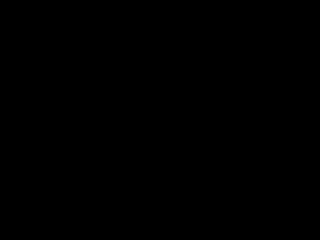

In [15]:
import mediapy as media


xml = """
<mujoco>
  <worldbody>
    <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
    <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
  </worldbody>
</mujoco>
"""
# Make model and data
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

# Make renderer, render and show the pixels
with mujoco.Renderer(model) as renderer:
  media.show_image(renderer.render())

Hmmm, why the black pixels?

**Answer:** For the same reason as above, we first need to propagate the values in `mjData`. This time we'll call [`mj_forward`](https://mujoco.readthedocs.io/en/latest/APIreference/APIfunctions.html#mj-forward), which invokes the entire pipeline up to the computation of accelerations i.e., it computes $\dot x = f(x)$, where $x$ is the state. This function does more than we actually need, but unless we care about saving computation time, it's good practice to call `mj_forward` since then we know we are not missing anything.

We also need to update the `mjvScene` which is an object held by the renderer describing the visual scene. We'll later see that the scene can include visual objects which are not part of the physical model.

""

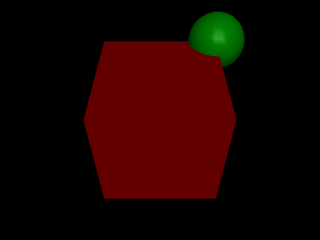

In [16]:
with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

""

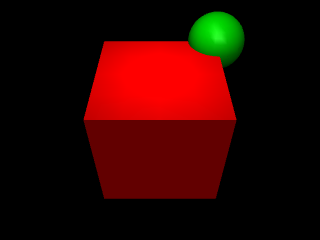

In [17]:
xml = """
<mujoco>
  <worldbody>
    <light name="top" pos="0 0 1"/>
    <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
    <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

## Simulation

Now let's simulate and make a video. We'll use MuJoCo's main high level function `mj_step`, which steps the state $x_{t+h} = f(x_t)$.

Note that in the code block below we are *not* rendering after each call to `mj_step`. This is because the default timestep is 2ms, and we want a 60fps video, not 500fps.

In [24]:
import imageio

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

imageio.mimsave('./video/output1.mp4', frames, fps=framerate)

[libopenh264 @ 0x2c566200] [OpenH264] this = 0x0x2c658f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x2c566200] [OpenH264] this = 0x0x2c658f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x2c566200] [OpenH264] this = 0x0x2c658f50, Warning:Change QP Range from(0,51) to (12,42)


In [25]:
xml = """
<mujoco>
  <worldbody>
    <light name="top" pos="0 0 1"/>
    <body name="box_and_sphere" euler="0 0 -30">
      <joint name="swing" type="hinge" axis="1 -1 0" pos="-.2 -.2 -.2"/>
      <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
      <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

# enable joint visualization option:
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, scene_option=scene_option)
      pixels = renderer.render()
      frames.append(pixels)

imageio.mimsave('./video/output2.mp4', frames, fps=framerate)

[libopenh264 @ 0x18bc0200] [OpenH264] this = 0x0x18cb2f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x18bc0200] [OpenH264] this = 0x0x18cb2f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x18bc0200] [OpenH264] this = 0x0x18cb2f50, Warning:Change QP Range from(0,51) to (12,42)


### Understanding Degrees of Freedom

In the real world, all rigid objects have 6 degrees-of-freedom: 3 translations and 3 rotations. Real-world joints act as constraints, removing relative degrees-of-freedom from bodies connected by joints. Some physics simulation software use this representation which is known as the "Cartesian" or "subtractive" representation, but it is inefficient. MuJoCo uses a representation known as the "Lagrangian", "generalized" or "additive" representation, whereby objects have no degrees of freedom unless explicitly added using joints.

Our model, which has a single hinge joint, has one degree of freedom, and the entire state is defined by this joint's angle and angular velocity. These are the system's generalized position and velocity.

In [41]:
print('Total number of DoFs in the model:', model.nv)
print('Generalized positions:', data.qpos)
print('Generalized velocities:', data.qvel)

Total number of DoFs in the model: 6
Generalized positions: [0.   0.   0.02 1.   0.   0.   0.  ]
Generalized velocities: [0. 0. 0. 0. 0. 0.]


\MuJoCo's use of generalized coordinates is the reason that calling a function (e.g. [`mj_forward`](https://mujoco.readthedocs.io/en/latest/APIreference.html#mj-forward)) is required before rendering or reading the global poses of objects – Cartesian positions are *derived* from the generalized positions and need to be explicitly computed.

# Example: Simulating free bodies with the self-inverting "tippe-top"

A free body is a body with a [free joint](https://www.google.com/url?sa=D&q=https%3A%2F%2Fmujoco.readthedocs.io%2Fen%2Flatest%2FXMLreference.html%3Fhighlight%3Dfreejoint%23body-freejoint) having 6 DoFs, i.e., 3 translations and 3 rotations. We could give our `box_and_sphere` body a free joint and watch it fall, but let's look at something more interesting. A "tippe top" is a spinning toy which flips itself ([video](https://www.youtube.com/watch?v=kbYpVrdcszQ), [Wikipedia](https://en.wikipedia.org/wiki/Tippe_top)). We model it as follows:

""

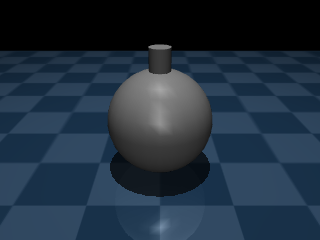

In [26]:
tippe_top = """
<mujoco model="tippe top">
  <option integrator="RK4"/>

  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>

  <worldbody>
    <geom size=".2 .2 .01" type="plane" material="grid"/>
    <light pos="0 0 .6"/>
    <camera name="closeup" pos="0 -.1 .07" xyaxes="1 0 0 0 1 2"/>
    <body name="top" pos="0 0 .02">
      <freejoint/>
      <geom name="ball" type="sphere" size=".02" />
      <geom name="stem" type="cylinder" pos="0 0 .02" size="0.004 .008"/>
      <geom name="ballast" type="box" size=".023 .023 0.005"  pos="0 0 -.015"
       contype="0" conaffinity="0" group="3"/>
    </body>
  </worldbody>

  <keyframe>
    <key name="spinning" qpos="0 0 0.02 1 0 0 0" qvel="0 0 0 0 1 200" />
  </keyframe>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(tippe_top)
data = mujoco.MjData(model)

mujoco.mj_forward(model, data)
with mujoco.Renderer(model) as renderer:
  renderer.update_scene(data, camera="closeup")

  media.show_image(renderer.render())

In [27]:
duration = 7    # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetDataKeyframe(model, data, 0)  # Reset the state to keyframe 0
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, "closeup")
      pixels = renderer.render()
      frames.append(pixels)

imageio.mimsave('./video/output3.mp4', frames, fps=framerate)

[libopenh264 @ 0x1a851200] [OpenH264] this = 0x0x1a943f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x1a851200] [OpenH264] this = 0x0x1a943f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x1a851200] [OpenH264] this = 0x0x1a943f50, Warning:Change QP Range from(0,51) to (12,42)


## Example: A chaotic pendulum

""

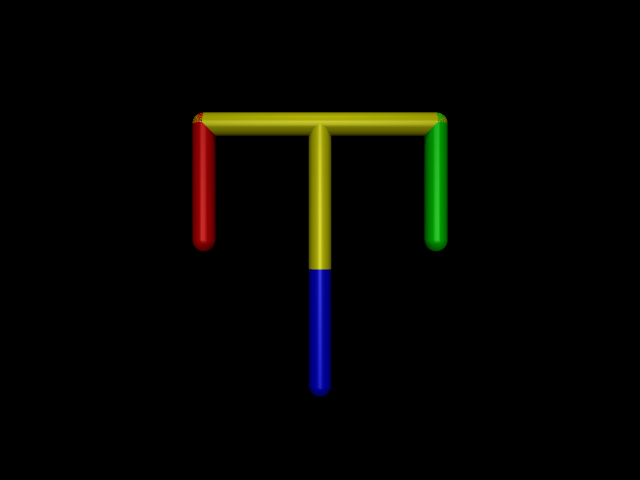

In [28]:
chaotic_pendulum = """
<mujoco>
  <option timestep=".001">
    <flag energy="enable" contact="disable"/>
  </option>

  <default>
    <joint type="hinge" axis="0 -1 0"/>
    <geom type="capsule" size=".02"/>
  </default>

  <worldbody>
    <light pos="0 -.4 1"/>
    <camera name="fixed" pos="0 -1 0" xyaxes="1 0 0 0 0 1"/>
    <body name="0" pos="0 0 .2">
      <joint name="root"/>
      <geom fromto="-.2 0 0 .2 0 0" rgba="1 1 0 1"/>
      <geom fromto="0 0 0 0 0 -.25" rgba="1 1 0 1"/>
      <body name="1" pos="-.2 0 0">
        <joint/>
        <geom fromto="0 0 0 0 0 -.2" rgba="1 0 0 1"/>
      </body>
      <body name="2" pos=".2 0 0">
        <joint/>
        <geom fromto="0 0 0 0 0 -.2" rgba="0 1 0 1"/>
      </body>
      <body name="3" pos="0 0 -.25">
        <joint/>
        <geom fromto="0 0 0 0 0 -.2" rgba="0 0 1 1"/>
      </body>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(chaotic_pendulum)
data = mujoco.MjData(model)
height = 480
width = 640

with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, camera="fixed")

  media.show_image(renderer.render())

In [30]:
import time

# setup
n_seconds = 6
framerate = 30  # Hz
n_frames = int(n_seconds * framerate)
frames = []
height = 240
width = 320

# set initial state
mujoco.mj_resetData(model, data)
data.joint('root').qvel = 10

# simulate and record frames
frame = 0
sim_time = 0
render_time = 0
n_steps = 0
with mujoco.Renderer(model, height, width) as renderer:
  for i in range(n_frames):
    while data.time * framerate < i:
      tic = time.time()
      mujoco.mj_step(model, data)
      sim_time += time.time() - tic
      n_steps += 1
    tic = time.time()
    renderer.update_scene(data, "fixed")
    frame = renderer.render()
    render_time += time.time() - tic
    frames.append(frame)

# print timing and play video
step_time = 1e6*sim_time/n_steps
step_fps = n_steps/sim_time
print(f'simulation: {step_time:5.3g} μs/step  ({step_fps:5.0f}Hz)')
frame_time = 1e6*render_time/n_frames
frame_fps = n_frames/render_time
print(f'rendering:  {frame_time:5.3g} μs/frame ({frame_fps:5.0f}Hz)')
print('\n')

# show video
imageio.mimsave('./video/output4.mp4', frames, fps=framerate)

simulation:   6.2 μs/step  (161228Hz)
rendering:  3.27e+03 μs/frame (  306Hz)




[libopenh264 @ 0x10e85200] [OpenH264] this = 0x0x10f77f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x10e85200] [OpenH264] this = 0x0x10f77f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x10e85200] [OpenH264] this = 0x0x10f77f50, Warning:Change QP Range from(0,51) to (12,42)



# Contacts

Let's go back to our box and sphere example and give it a free joint:

""

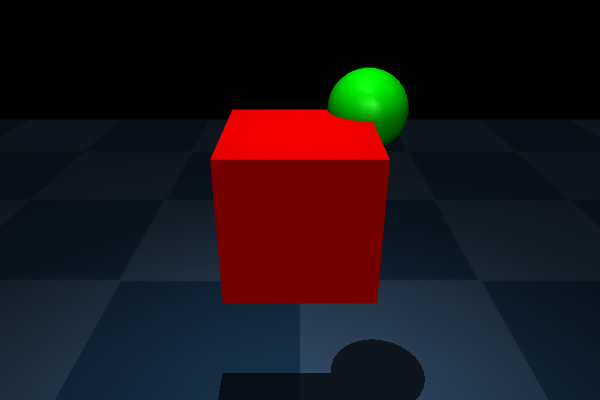

In [ ]:
free_body_MJCF = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
    rgb2=".2 .3 .4" width="300" height="300" mark="edge" markrgb=".2 .3 .4"/>
    <material name="grid" texture="grid" texrepeat="2 2" texuniform="true"
    reflectance=".2"/>
  </asset>

  <worldbody>
    <light pos="0 0 1" mode="trackcom"/>
    <geom name="ground" type="plane" pos="0 0 -.5" size="2 2 .1" material="grid" solimp=".99 .99 .01" solref=".001 1"/>
    <body name="box_and_sphere" pos="0 0 0">
      <freejoint/>
      <geom name="red_box" type="box" size=".1 .1 .1" rgba="1 0 0 1" solimp=".99 .99 .01"  solref=".001 1"/>
      <geom name="green_sphere" size=".06" pos=".1 .1 .1" rgba="0 1 0 1"/>
      <camera name="fixed" pos="0 -.6 .3" xyaxes="1 0 0 0 1 2"/>
      <camera name="track" pos="0 -.6 .3" xyaxes="1 0 0 0 1 2" mode="track"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(free_body_MJCF)
data = mujoco.MjData(model)
height = 400
width = 600

with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, "fixed")

  media.show_image(renderer.render())

In [34]:
import numpy as np


n_frames = 200
height = 240
width = 320
frames = []

# visualize contact frames and forces, make body transparent
options = mujoco.MjvOption()
mujoco.mjv_defaultOption(options)
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
options.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

# tweak scales of contact visualization elements
model.vis.scale.contactwidth = 0.1
model.vis.scale.contactheight = 0.03
model.vis.scale.forcewidth = 0.05
model.vis.map.force = 0.3

# random initial rotational velocity:
mujoco.mj_resetData(model, data)
data.qvel[3:6] = 5*np.random.randn(3)

# Simulate and display video.
with mujoco.Renderer(model, height, width) as renderer:
  for i in range(n_frames):
    while data.time < i/120.0: #1/4x real time
      mujoco.mj_step(model, data)
    renderer.update_scene(data, "track", options)
    frame = renderer.render()
    frames.append(frame)

  imageio.mimsave('./video/output5.mp4', frames, fps=framerate)

[libopenh264 @ 0x2d7df200] [OpenH264] this = 0x0x2d8d1f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x2d7df200] [OpenH264] this = 0x0x2d8d1f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x2d7df200] [OpenH264] this = 0x0x2d8d1f50, Warning:Change QP Range from(0,51) to (12,42)


## Friction

Let's see the effect of changing friction values

In [37]:
MJCF = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300" mark="none"/>
    <material name="grid" texture="grid" texrepeat="6 6"
     texuniform="true" reflectance=".2"/>
     <material name="wall" rgba='.5 .5 .5 1'/>
  </asset>

  <default>
    <geom type="box" size=".05 .05 .05" />
    <joint type="free"/>
  </default>

  <worldbody>
    <light name="light" pos="-.2 0 1"/>
    <geom name="ground" type="plane" size=".5 .5 10" material="grid"
     zaxis="-.3 0 1" friction=".1"/>
    <camera name="y" pos="-.1 -.6 .3" xyaxes="1 0 0 0 1 2"/>
    <body pos="0 0 .1">
      <joint/>
      <geom/>
    </body>
    <body pos="0 .2 .1">
      <joint/>
      <geom friction=".33"/>
    </body>
  </worldbody>

</mujoco>
"""
n_frames = 60
height = 300
width = 300
frames = []

# load
model = mujoco.MjModel.from_xml_string(MJCF)
data = mujoco.MjData(model)

# Simulate and display video.
with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_resetData(model, data)
  for i in range(n_frames):
    while data.time < i/30.0:
      mujoco.mj_step(model, data)
    renderer.update_scene(data, "y")
    frame = renderer.render()
    frames.append(frame)

imageio.mimsave('./video/output6.mp4', frames, fps=framerate)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (300, 300) to (304, 304) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[libopenh264 @ 0x5a74200] [OpenH264] this = 0x0x5b77550, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x5a74200] [OpenH264] this = 0x0x5b77550, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x5a74200] [OpenH264] this = 0x0x5b77550, Warning:Change QP Range from(0,51) to (12,42)


# Tendons, actuators and sensors

""

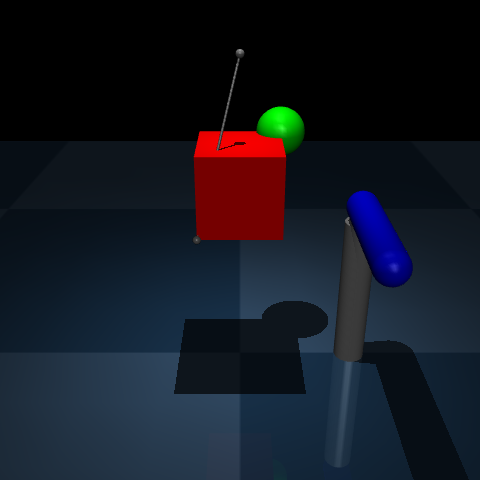

In [38]:
MJCF = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300" mark="none"/>
    <material name="grid" texture="grid" texrepeat="1 1"
     texuniform="true" reflectance=".2"/>
  </asset>

  <worldbody>
    <light name="light" pos="0 0 1"/>
    <geom name="floor" type="plane" pos="0 0 -.5" size="2 2 .1" material="grid"/>
    <site name="anchor" pos="0 0 .3" size=".01"/>
    <camera name="fixed" pos="0 -1.3 .5" xyaxes="1 0 0 0 1 2"/>

    <geom name="pole" type="cylinder" fromto=".3 0 -.5 .3 0 -.1" size=".04"/>
    <body name="bat" pos=".3 0 -.1">
      <joint name="swing" type="hinge" damping="1" axis="0 0 1"/>
      <geom name="bat" type="capsule" fromto="0 0 .04 0 -.3 .04"
       size=".04" rgba="0 0 1 1"/>
    </body>

    <body name="box_and_sphere" pos="0 0 0">
      <joint name="free" type="free"/>
      <geom name="red_box" type="box" size=".1 .1 .1" rgba="1 0 0 1"/>
      <geom name="green_sphere"  size=".06" pos=".1 .1 .1" rgba="0 1 0 1"/>
      <site name="hook" pos="-.1 -.1 -.1" size=".01"/>
      <site name="IMU"/>
    </body>
  </worldbody>

  <tendon>
    <spatial name="wire" limited="true" range="0 0.35" width="0.003">
      <site site="anchor"/>
      <site site="hook"/>
    </spatial>
  </tendon>

  <actuator>
    <motor name="my_motor" joint="swing" gear="1"/>
  </actuator>

  <sensor>
    <accelerometer name="accelerometer" site="IMU"/>
  </sensor>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(MJCF)
data = mujoco.MjData(model)
height = 480
width = 480

with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, "fixed")

  media.show_image(renderer.render())

actuated bat and passive "piñata":

In [39]:
n_frames = 180
height = 240
width = 320
frames = []
fps = 60.0
times = []
sensordata = []

# constant actuator signal
mujoco.mj_resetData(model, data)
data.ctrl = 20

# Simulate and display video.
with mujoco.Renderer(model, height, width) as renderer:
  for i in range(n_frames):
    while data.time < i/fps:
      mujoco.mj_step(model, data)
      times.append(data.time)
      sensordata.append(data.sensor('accelerometer').data.copy())
    renderer.update_scene(data, "fixed")
    frame = renderer.render()
    frames.append(frame)

imageio.mimsave('./video/output7.mp4', frames, fps=framerate)

[libopenh264 @ 0x38e53200] [OpenH264] this = 0x0x38f45f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x38e53200] [OpenH264] this = 0x0x38f45f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x38e53200] [OpenH264] this = 0x0x38f45f50, Warning:Change QP Range from(0,51) to (12,42)


Let's plot the values measured by our accelerometer sensor:

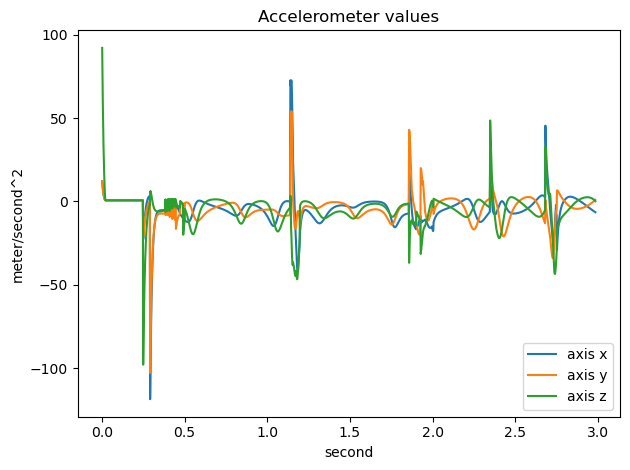

In [41]:
import matplotlib.pyplot as plt


ax = plt.gca()

ax.plot(np.asarray(times), np.asarray(sensordata), label=[f"axis {v}" for v in ['x', 'y', 'z']])

# finalize plot
ax.set_title('Accelerometer values')
ax.set_ylabel('meter/second^2')
ax.set_xlabel('second')
ax.legend(frameon=True, loc='lower right')
plt.tight_layout()

## Advanced rendering

Like joint visualization, additional rendering options are exposed as parameters to the `render` method.

Let's bring back our first model:

""

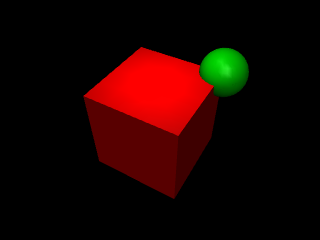

In [42]:
xml = """
<mujoco>
  <worldbody>
    <light name="top" pos="0 0 1"/>
    <body name="box_and_sphere" euler="0 0 -30">
      <joint name="swing" type="hinge" axis="1 -1 0" pos="-.2 -.2 -.2"/>
      <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
      <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)
  media.show_image(renderer.render())

### Enable transparency and frame visualization


""

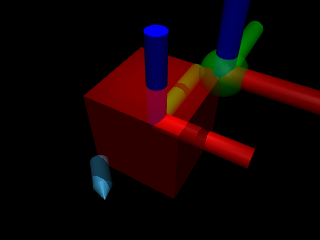

In [43]:
#@title Enable transparency and frame visualization {vertical-output: true}

scene_option.frame = mujoco.mjtFrame.mjFRAME_GEOM
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
with mujoco.Renderer(model) as renderer:
  renderer.update_scene(data, scene_option=scene_option)
  frame = renderer.render()
  media.show_image(frame)

### Depth rendering

In [45]:
#@title Depth rendering {vertical-output: true}

with mujoco.Renderer(model) as renderer:
  # update renderer to render depth
  renderer.enable_depth_rendering()

  # reset the scene
  renderer.update_scene(data)

  # depth is a float array, in meters.
  depth = renderer.render()

  # Shift nearest values to the origin.
  depth -= depth.min()
  # Scale by 2 mean distances of near rays.
  depth /= 2*depth[depth <= 1].mean()
  # Scale to [0, 255]
  pixels = 255*np.clip(depth, 0, 1)

  imageio.mimsave('./video/output8.mp4', frames, fps=framerate)

[libopenh264 @ 0xa949200] [OpenH264] this = 0x0xaa3bf50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0xa949200] [OpenH264] this = 0x0xaa3bf50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0xa949200] [OpenH264] this = 0x0xaa3bf50, Warning:Change QP Range from(0,51) to (12,42)


### Segmentation rendering

In [46]:
#@title Segmentation rendering {vertical-output: true}

with mujoco.Renderer(model) as renderer:
  renderer.disable_depth_rendering()

  # update renderer to render segmentation
  renderer.enable_segmentation_rendering()

  # reset the scene
  renderer.update_scene(data)

  seg = renderer.render()

  # Display the contents of the first channel, which contains object
  # IDs. The second channel, seg[:, :, 1], contains object types.
  geom_ids = seg[:, :, 0]
  # Infinity is mapped to -1
  geom_ids = geom_ids.astype(np.float64) + 1
  # Scale to [0, 1]
  geom_ids = geom_ids / geom_ids.max()
  pixels = 255*geom_ids
  imageio.mimsave('./video/output9.mp4', frames, fps=framerate)

[libopenh264 @ 0x2ba7e200] [OpenH264] this = 0x0x2bb70f50, Warning:layerId(0) doesn't support profile(578), change to UNSPECIFIC profile
[libopenh264 @ 0x2ba7e200] [OpenH264] this = 0x0x2bb70f50, Warning:bEnableFrameSkip = 0,bitrate can't be controlled for RC_QUALITY_MODE,RC_BITRATE_MODE and RC_TIMESTAMP_MODE without enabling skip frame.
[libopenh264 @ 0x2ba7e200] [OpenH264] this = 0x0x2bb70f50, Warning:Change QP Range from(0,51) to (12,42)


### The camera matrix

For a description of the camera matrix see the article [Camera matrix](https://en.wikipedia.org/wiki/Camera_matrix) on Wikipedia.

In [47]:
def compute_camera_matrix(renderer, data):
  """Returns the 3x4 camera matrix."""
  # If the camera is a 'free' camera, we get its position and orientation
  # from the scene data structure. It is a stereo camera, so we average over
  # the left and right channels. Note: we call `self.update()` in order to
  # ensure that the contents of `scene.camera` are correct.
  renderer.update_scene(data)
  pos = np.mean([camera.pos for camera in renderer.scene.camera], axis=0)
  z = -np.mean([camera.forward for camera in renderer.scene.camera], axis=0)
  y = np.mean([camera.up for camera in renderer.scene.camera], axis=0)
  rot = np.vstack((np.cross(y, z), y, z))
  fov = model.vis.global_.fovy

  # Translation matrix (4x4).
  translation = np.eye(4)
  translation[0:3, 3] = -pos

  # Rotation matrix (4x4).
  rotation = np.eye(4)
  rotation[0:3, 0:3] = rot

  # Focal transformation matrix (3x4).
  focal_scaling = (1./np.tan(np.deg2rad(fov)/2)) * renderer.height / 2.0
  focal = np.diag([-focal_scaling, focal_scaling, 1.0, 0])[0:3, :]

  # Image matrix (3x3).
  image = np.eye(3)
  image[0, 2] = (renderer.width - 1) / 2.0
  image[1, 2] = (renderer.height - 1) / 2.0
  return image @ focal @ rotation @ translation

## Project from world to camera coordinates


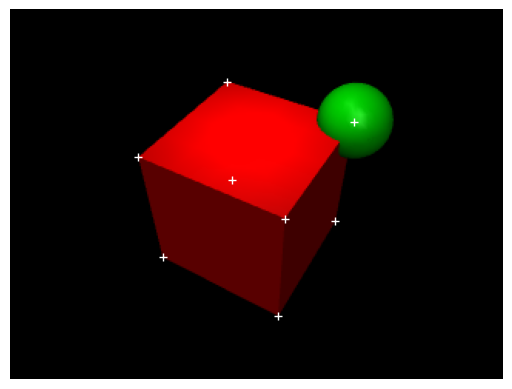

In [49]:
import itertools

#@title Project from world to camera coordinates {vertical-output: true}

with mujoco.Renderer(model) as renderer:
  renderer.disable_segmentation_rendering()
  # reset the scene
  renderer.update_scene(data)

  # Get the world coordinates of the box corners
  box_pos = data.geom_xpos[model.geom('red_box').id]
  box_mat = data.geom_xmat[model.geom('red_box').id].reshape(3, 3)
  box_size = model.geom_size[model.geom('red_box').id]
  offsets = np.array([-1, 1]) * box_size[:, None]
  xyz_local = np.stack(list(itertools.product(*offsets))).T
  xyz_global = box_pos[:, None] + box_mat @ xyz_local

  # Camera matrices multiply homogenous [x, y, z, 1] vectors.
  corners_homogeneous = np.ones((4, xyz_global.shape[1]), dtype=float)
  corners_homogeneous[:3, :] = xyz_global

  # Get the camera matrix.
  m = compute_camera_matrix(renderer, data)

  # Project world coordinates into pixel space. See:
  # https://en.wikipedia.org/wiki/3D_projection#Mathematical_formula
  xs, ys, s = m @ corners_homogeneous
  # x and y are in the pixel coordinate system.
  x = xs / s
  y = ys / s

  # Render the camera view and overlay the projected corner coordinates.
  pixels = renderer.render()
  fig, ax = plt.subplots(1, 1)
  ax.imshow(pixels)
  ax.plot(x, y, '+', c='w')
  ax.set_axis_off()

In [ ]:
#@title Render from moving camera

duration = 3  # (seconds)
height = 1024
width = 1440

# find time when box is thrown (speed > 2cm/s)
throw_time = 0.0
mujoco.mj_resetData(model, data)
while data.time < duration and not throw_time:
  mujoco.mj_step(model, data)
  box_speed = np.linalg.norm(data.joint('swing').qvel[:3])
  if box_speed > 0.02:
    throw_time = data.time
assert throw_time > 0

def mix(time, t0=0.0, width=1.0):
  """Sigmoidal mixing function."""
  t = (time - t0) / width
  s = 1 / (1 + np.exp(-t))
  return 1 - s, s

def unit_cos(t):
  """Unit cosine sigmoid from (0,0) to (1,1)."""
  return 0.5 - np.cos(np.pi*np.clip(t, 0, 1))/2

def orbit_motion(t):
  """Return orbit trajectory."""
  distance = 0.9
  azimuth = 140 + 100 * unit_cos(t)
  elevation = -30
  lookat = data.geom('floor').xpos.copy()
  return distance, azimuth, elevation, lookat

def track_motion():
  """Return box-track trajectory."""
  distance = 0.08
  azimuth = 280
  elevation = -10
  lookat = data.geom('box').xpos.copy()
  return distance, azimuth, elevation, lookat

def cam_motion():
  """Return sigmoidally-mixed {orbit, box-track} trajectory."""
  d0, a0, e0, l0 = orbit_motion(data.time / throw_time)
  d1, a1, e1, l1 = track_motion()
  mix_time = 0.3
  w0, w1 = mix(data.time, throw_time, mix_time)
  return w0*d0+w1*d1, w0*a0+w1*a1, w0*e0+w1*e1, w0*l0+w1*l1

# Make a camera.
cam = mujoco.MjvCamera()
mujoco.mjv_defaultCamera(cam)

# Simulate and display video.
framerate = 60  # (Hz)
slowdown = 4    # 4x slow-down
mujoco.mj_resetData(model, data)
frames = []
with mujoco.Renderer(model, height, width) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate * slowdown:
      cam.distance, cam.azimuth, cam.elevation, cam.lookat = cam_motion()
      renderer.update_scene(data, cam)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

ValueError: Image width 1440 > framebuffer width 640. Either reduce the image
width or specify a larger offscreen framebuffer in the model XML using the
clause:
<visual>
  <global offwidth="my_width"/>
</visual>

## More On he MuJoco

> This is the model gallery for more desgins : https://mujoco.readthedocs.io/en/stable/models.html